# SkillCorner Data Exploration — Coach/Scout Film-Clip Retrieval App (Real Data)

**Project:** Structured-filtering retrieval system that turns a coach's natural-language
question into a ranked list of film-clip segments, backed by SkillCorner broadcast
tracking data + derived Dynamic Events (from the [SkillCorner Open Data repo](https://github.com/SkillCorner/opendata)).

**This notebook now runs against real data.** The first pass (kept in git history) used
synthetic data matching the schema exactly, since that chat's sandbox had no network
access. This environment does, so this version loads a real match's `_dynamic_events.csv`
directly. The upstream repo currently has **20** matches (not 10, as originally assumed
from the README) — `data/matches.json` lists them all.

**To fetch data:** `scripts/fetch_match_data.sh <match_id>` pulls one match's
`_match.json` / `_dynamic_events.csv` / `_phases_of_play.csv` into `data/matches/<id>/`
(gitignored). This notebook defaults to match `1874553` (Brisbane FC vs Adelaide United,
A-League 2024/25) for readable single-match examples; `scripts/test_all_questions.py`
runs the full 80-question test set across every match fetched locally and writes results
to `docs/real_data_validation.md` — see that doc for the exhaustive pass. `{id}_tracking_extrapolated.jsonl`
is Git-LFS-only upstream and hasn't been pulled (see the pitch-plot section below for what
that limits).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

DATA_DIR = Path("data/matches")
MATCH_ID = "1874553"


## 1. Load a real match's dynamic events

No synthetic generator here — this is `1874553_dynamic_events.csv` exactly as published
by SkillCorner.

In [2]:
events = pd.read_csv(DATA_DIR / MATCH_ID / f"{MATCH_ID}_dynamic_events.csv", low_memory=False)
match_info = json.load(open(DATA_DIR / MATCH_ID / f"{MATCH_ID}_match.json"))
print(f"{match_info['home_team']['short_name']} vs {match_info['away_team']['short_name']}")
print(f"{len(events)} dynamic events, {events['event_id'].nunique()} unique event_ids, {events.shape[1]} columns")
events.head(3)


Brisbane FC vs Adelaide United
4915 dynamic events, 4915 unique event_ids, 322 columns


,event_id,index,match_id,frame_start,frame_end,frame_physical_start,time_start,time_end,minute_start,second_start,duration,period,attacking_side_id,attacking_side,event_type_id,event_type,event_subtype_id,event_subtype,player_id,player_name,player_position_id,player_position,player_in_possession_id,player_in_possession_name,player_in_possession_position_id,player_in_possession_position,team_id,team_shortname,x_start,y_start,...,affected_line_breaking_passing_option_xthreat,affected_line_breaking_passing_option_dangerous,affected_line_breaking_passing_option_run_subtype_id,affected_line_breaking_passing_option_run_subtype,pressing_chain,pressing_chain_length,pressing_chain_end_type_id,pressing_chain_end_type,pressing_chain_index,index_in_pressing_chain,simultaneous_defensive_engagement_same_target,simultaneous_defensive_engagement_same_target_rank,consecutive_on_ball_engagements,is_player_possession_start_matched,is_player_possession_end_matched,is_previous_pass_matched,is_pass_reception_matched,fully_extrapolated,possession_epv_for_start,possession_epv_for_end,possession_epv_against_start,possession_epv_against_end,pass_reception_epv_for,pass_reception_epv_against,possession_epv_total,pass_epv_total,possession_epv_delta_for,possession_epv_delta_against,pass_epv_delta_for,pass_epv_delta_against
0,8_0,0,1874553,29,29,NaN,00:01.9,00:01.9,0,1,0.0,1,1,left_to_right,8,player_possession,NaN,NaN,50973,J. Caletti,11,RDM,NaN,NaN,NaN,NaN,1802,Brisbane FC,0.30,0.23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True,NaN,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1_0,1,1874553,32,54,NaN,00:02.2,00:04.4,0,2,2.2,1,1,left_to_right,1,off_ball_run,8.0,run_ahead_of_the_ball,560986,K. Jelacic,17,RW,51050.0,B. Warland,4.0,LCB,1802,Brisbane FC,1.65,-28.38,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8_1,2,1874553,42,60,NaN,00:03.2,00:05.0,0,3,1.8,1,1,left_to_right,8,player_possession,NaN,NaN,51050,B. Warland,4,LCB,NaN,NaN,NaN,NaN,1802,Brisbane FC,-19.16,3.18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,True,True,True,False,NaN,NaN,NaN,NaN,0.0247,0.0158,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Sanity-check the shape of the data

Distribution of event types and phases of play — the same check the synthetic pass ran,
now against the real distribution.

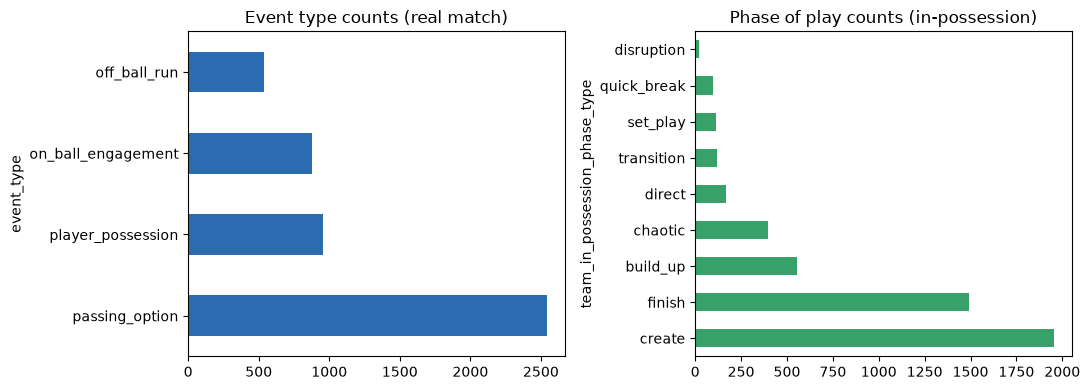

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
events['event_type'].value_counts().plot(kind='barh', ax=axes[0], color="#2b6cb0")
axes[0].set_title("Event type counts (real match)")
events['team_in_possession_phase_type'].value_counts().plot(kind='barh', ax=axes[1], color="#38a169")
axes[1].set_title("Phase of play counts (in-possession)")
plt.tight_layout()
plt.show()


## 3. Working the coach question test set against the real schema

Same 4 representative queries the synthetic pass ran (one per category: event-type,
spatial, sequence, negative/absence), now against real data. See
`docs/real_data_validation.md` for the full writeup and `scripts/validate_real_data.py`
for a standalone script version of just these 4.

### Q1 (event-type category): *"Show me all shots taken from outside the box."*
A shot is a `player_possession` event whose `end_type == 'shot'`. "Outside the box" is
`penalty_area_end == False` at the location the possession ended. Same one-line filter as
the synthetic pass — confirmed on real data.

In [4]:
q1 = events[(events.event_type == "player_possession") &
            (events.end_type == "shot") &
            (events.penalty_area_end == False)]
print(f"Q1 hits: {len(q1)}")
q1[["event_id","minute_start","player_name","team_shortname","x_end","y_end"]]


Q1 hits: 6


,event_id,minute_start,player_name,team_shortname,x_end,y_end
273,8_56,5,K. Jelacic,Brisbane FC,34.43,12.77
1249,8_244,23,J. Caletti,Brisbane FC,32.63,1.33
2892,8_575,52,B. Halloran,Brisbane FC,34.12,7.34
3569,8_706,65,A. Burke-Gilroy,Brisbane FC,24.56,0.37
3862,8_756,72,E. Alagich,Adelaide United,35.29,9.92
4560,8_888,87,J. Brazete,Brisbane FC,34.33,13.31


### Q2 (spatial category): *"Show me all plays where their left winger cut inside at the top of the box."*
`out_to_in` is a native boolean field — no geometry needed to derive it.

In [5]:
q2 = events[(events.player_position.isin(["LW","RW"])) &
            (events.out_to_in == True) &
            (events.third_end == "attacking_third") &
            (events.x_end.between(20, 40))]
print(f"Q2 hits: {len(q2)}")
q2[["event_id","minute_start","player_name","channel_start","channel_end","x_end","y_end"]]


Q2 hits: 15


,event_id,minute_start,player_name,channel_start,channel_end,x_end,y_end
8,1_1,0,K. Jelacic,wide_right,center,36.16,-9.13
186,1_21,3,A. Ayoubi,wide_left,center,39.74,6.24
727,7_369,12,Z. Clough,wide_right,half_space_right,33.37,-18.67
870,1_98,17,A. Ayoubi,wide_left,half_space_left,29.45,14.54
1288,1_133,24,B. Halloran,wide_left,half_space_left,37.47,13.44
1291,7_669,24,B. Halloran,wide_left,half_space_left,34.32,16.34
1925,7_1008,33,Z. Clough,wide_right,half_space_right,35.35,-17.82
2083,7_1097,36,K. Jelacic,wide_right,half_space_right,24.02,-19.94
2284,1_222,38,Z. Clough,half_space_right,center,35.29,-3.27
3170,1_331,57,B. Folami,wide_left,half_space_left,23.64,13.85


### Q3 (sequence category): *"Show me every sequence that started with a regain in midfield and ended in a shot within 10 seconds."*
`lead_to_shot` handles the 10-second window natively. One real-data adjustment versus the
synthetic pass: `start_type` needs `.isin(["recovery", "pass_interception"])`, not just
`"recovery"` — a regain can resolve either way in the real data, and the synthetic
generator only ever produced `"recovery"`.

In [6]:
q3 = events[(events.event_type == "player_possession") &
            (events.start_type.isin(["recovery", "pass_interception"])) &
            (events.third_start == "middle_third") &
            (events.lead_to_shot == True)]
print(f"Q3 hits: {len(q3)}")
q3[["event_id","minute_start","player_name","team_shortname","start_type","third_start"]]


Q3 hits: 3


,event_id,minute_start,player_name,team_shortname,start_type,third_start
1829,8_359,32,A. Ayoubi,Adelaide United,recovery,middle_third
4203,8_819,80,J. Yull,Adelaide United,pass_interception,middle_third
4801,8_936,93,J. Yull,Adelaide United,pass_interception,middle_third


### Q4 (negative/absence category): *"Show me every time their striker did not press the center back after a goal kick."*
The anti-join pattern from the synthetic pass, unchanged: find goal-kick windows
(`phase_index`), then anti-join against `on_ball_engagement` rows by a CF in the same
phase.

In [7]:
goal_kick_windows = events[(events.game_interruption_before.isin(["goal_kick_for", "goal_kick_against"]))]
striker_presses = events[(events.event_type == "on_ball_engagement") & (events.player_position == "CF")]

merged = goal_kick_windows.merge(
    striker_presses[["phase_index"]].drop_duplicates(),
    on="phase_index", how="left", indicator=True
)
q4 = merged[merged["_merge"] == "left_only"]
print(f"Goal-kick windows: {len(goal_kick_windows)} | with a CF press: {len(goal_kick_windows) - len(q4)} | WITHOUT a CF press (Q4 hits): {len(q4)}")
q4[["event_id","minute_start","team_shortname","game_interruption_before"]].head(6)


Goal-kick windows: 31 | with a CF press: 13 | WITHOUT a CF press (Q4 hits): 18


/tmp/ipykernel_1599/2104620817.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged = goal_kick_windows.merge(
/tmp/ipykernel_1599/2104620817.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged = goal_kick_windows.merge(


,event_id,minute_start,team_shortname,game_interruption_before
0,9_37,3,Brisbane FC,goal_kick_for
1,8_38,3,Adelaide United,goal_kick_against
2,8_118,10,Adelaide United,goal_kick_for
3,9_115,10,Brisbane FC,goal_kick_against
6,8_302,28,Brisbane FC,goal_kick_for
7,8_394,35,Brisbane FC,goal_kick_for


### The full 80-question test set

The 4 queries above generalize: `scripts/test_all_questions.py` runs all 80 questions from
`coach_question_test_set.md` across every match fetched locally (20 matches / 94,517 events
as of this pass), tagging each with a fidelity level (`exact` / `approximate` /
`unresolved`). Headline result: **47 exact, 22 approximate, 11 unresolved**. Full results,
per-question notes, and the real schema gotchas that pass caught (e.g. `give_and_go` only
lives on `off_ball_run` rows; `penalty_area_start`/`_end` only ever flags the *attacking*
box, never the defensive one) are in `docs/real_data_validation.md` — not duplicated here
since the script is the source of truth for the actual query logic.

## 4. Event locations on the pitch (real tracking data not yet available)

Real per-frame tracking (`{id}_tracking_extrapolated.jsonl`) is Git-LFS-only in the
upstream repo and hasn't been pulled — a plain `git clone` leaves it as an LFS pointer
stub. It's needed for exact frame-by-frame animation (what a real clip would look like)
and for the handful of test-set questions that need multi-player geometry at a single
instant (e.g. "dragged out of position", "foot race" — see `docs/real_data_validation.md`).

What real data *does* give us without it: every event row already carries `x_start`/`y_start`,
so we can at least plot where a real player's touches actually happened on the pitch,
as a stand-in for the frame-by-frame pitch plot the synthetic pass used a single made-up
frame for.

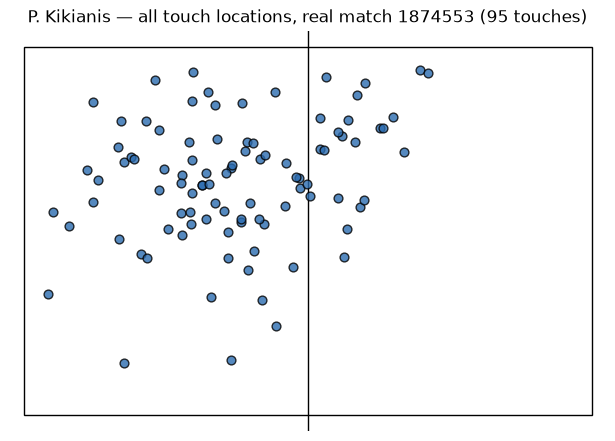

In [8]:
top_player = events[events.event_type == "player_possession"]["player_name"].value_counts().idxmax()
touches = events[(events.event_type == "player_possession") & (events.player_name == top_player)]

fig, ax = plt.subplots(figsize=(8,5.2))
ax.add_patch(plt.Rectangle((-52.5,-34),105,68, fill=False, color="black"))
ax.axvline(0, color="black", lw=1)
ax.scatter(touches["x_start"], touches["y_start"], s=40, color="#2b6cb0", edgecolor="black", alpha=0.8, zorder=3)
ax.set_xlim(-55,55); ax.set_ylim(-37,37); ax.set_aspect("equal"); ax.axis("off")
ax.set_title(f"{top_player} — all touch locations, real match {MATCH_ID} ({len(touches)} touches)")
plt.show()


## 5. Takeaways (real data)

- **The core architectural bet holds up on real data at scale, not just one match.**
  Across all 80 test-set questions and 20 real matches: 47 resolve exactly as direct field
  filters (or anti-joins), 22 resolve with a documented approximation, and only 11 are
  genuinely unresolved with the current schema. See `docs/real_data_validation.md` for the
  full table.
- **Comparative/relational questions (Category 6) turned out to need raw tracking data far
  less than this notebook's synthetic-data pass assumed.** `separation_start/end`,
  `interplayer_distance`, and `n_teammates_ahead_start/end` are already per-event columns —
  6 of 10 questions in that category resolved without touching tracking data at all.
- **Negative/absence questions confirmed as needing genuinely different query code**
  (anti-joins over `phase_index` windows), exactly as the synthetic pass predicted — this
  generalized cleanly to 10 questions in the full pass, not just the one example here.
- **Building 80 real queries surfaced 3 "which event_type is this field actually populated
  on" gotchas** that a 4-query pass wouldn't have forced out (`give_and_go` only on
  `off_ball_run`; `penalty_area_start/end` only on the attacking side; a few fields only on
  `player_possession` rows). All three were bugs in the query layer, not evidence against
  the schema/architecture — worth remembering as a general lesson for whatever eventually
  writes the real query-parsing chain.
- **11 unresolved questions cluster into 4 concrete gaps**: no captain flag, no
  goal-timestamp field to anchor "N minutes after scoring" windows, a few team-shape/
  multi-player-geometry questions that need raw tracking frames, and a handful of concepts
  with no schema tag at all (offside, "tracked back", defender rotation). This is a scoped
  backlog, not a broad architecture problem.
- **Next step once `_tracking_extrapolated.jsonl` is pulled** (needs Git LFS credentials
  for `SkillCorner/opendata`, not available in this environment): re-validate the
  tracking-dependent minority of questions, and build the real frame-by-frame clip
  rendering this whole project is ultimately for.